# METHODS

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmocean as cm

from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FixedLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes  # plain Matplotlib Axes for colorbar

In [2]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [3]:
##ports
Puertos = {
       "Pisco":  [-13.69388889,  -76.22416667],
    # "Callao":   [-12.0575,  -77.15305556],
    "Chimbote": [-9.076666667,  -78.61472222],
    "Paita":    [-5.078055556,  -81.10638889],
    }

In [4]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [5]:
wmld = xr.open_dataset('../W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld, 'WMLD', 250)  # ~111 km cross-shore

wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-16.1,-4.9))
wmld

<xarray.Dataset> Size: 92MB
Dimensions:  (time: 432, lat: 137, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.03 -15.95 -15.87 ... -5.076 -4.993 -4.91
Data variables:
    WMLD     (time, lat, lon) float64 92MB nan nan nan nan ... nan nan nan nan

In [6]:
# ============================================================
# 3. Find coastal and offshore boundary longitudes per latitude
# ============================================================
valid = np.isfinite(wmld.WMLD.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
valid_w = valid.shift(lon=+1).fillna(False).astype(bool)

coast_mask = valid & (~valid_e)      # easternmost valid cell (coast)
offshore_mask = valid & (~valid_w)   # westernmost valid cell (offshore edge)

lat_all = wmld.lat.values
lon_all = wmld.lon.values

coast_lons = np.full(len(lat_all), np.nan)
offshore_lons = np.full(len(lat_all), np.nan)

for j in range(len(lat_all)):
    cols_e = np.where(coast_mask.isel(lat=j).values)[0]
    if len(cols_e) > 0:
        coast_lons[j] = lon_all[cols_e[0]]
    cols_w = np.where(offshore_mask.isel(lat=j).values)[0]
    if len(cols_w) > 0:
        offshore_lons[j] = lon_all[cols_w[0]]

In [7]:
A = 6371000.0
widths = np.full(len(lat_all), np.nan)
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        widths[j] = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))

widths_da = xr.DataArray(widths, dims='lat', coords={'lat': lat_all}, name='cross_shore_width')

# widths_da

In [8]:
wmld__ = xr.open_dataset('../W_mld_Croco.nc').compute()
wmld__ = wmld__.where(wmld__!=0,np.nan)

wmld_full_mean = (wmld__ * 60 * 60 * 24).WMLD.mean('time')

Lat  -5 → closest index    135 | coast=-81.20 | offshore=-83.45
Lat -16 → closest index      0 | coast=-74.12 | offshore=-76.45


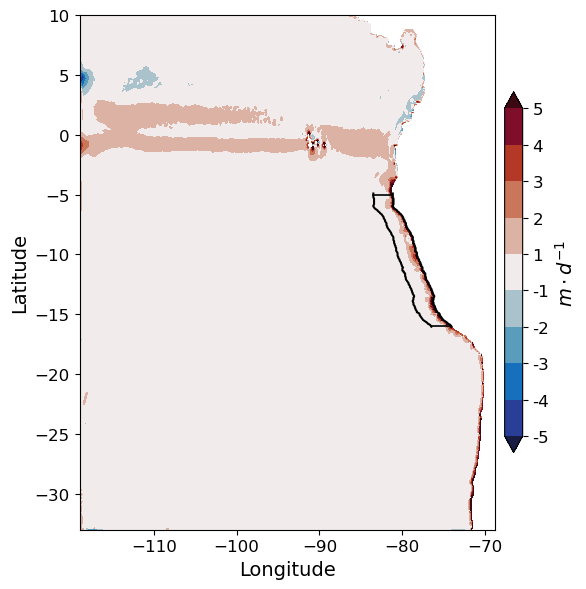

In [9]:
from matplotlib.colors import TwoSlopeNorm 
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(6,6))

# --- Background field with proper levels ---
vmin=-5; vmax=5
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

levels=np.linspace(vmin,vmax,10)

cf = wmld_full_mean.plot.contourf(
    ax=ax,
    cmap=cm.cm.balance,
    levels=levels,
    vmin=vmin, vmax=vmax,norm=norm,
    add_colorbar=False
)

# --- Proper colorbar linked to contourf ---
cbar = plt.colorbar(cf, ax=ax, pad=0.02,shrink=0.7)
cbar.set_label(r'$m \cdot d^{-1}$', fontsize=14)

# ticks every 0.5 (already matches levels, but enforce clean formatting)
# cbar.set_ticks(np.arange(-5, 5, 1)) 
cbar.ax.tick_params(labelsize=12)

# --- Coast and offshore limits ---
ax.plot(coast_lons + 0.05, lat_all, color='black', label='coast')
ax.plot(offshore_lons - 0.05, lat_all, color='black', label='offshore')

# ============================================================
# Cross-shore lines at exact integer latitudes
# ============================================================
target_lats = [-5, -16]

for lat0 in target_lats:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c = coast_lons[j]
    lon_o = offshore_lons[j]
    
    print(f"Lat {lat0:3d} → closest index {j:6d} | coast={lon_c:.2f} | offshore={lon_o:.2f}")  # DEBUG
    
    if not (np.isfinite(lon_c) and np.isfinite(lon_o)):
        print(f"    → Skipped (NaN values)")
        continue
        
    dx = 1.05 * abs(lon_c - lon_o)
    x0 = lon_c - np.sign(lon_c - lon_o) * dx
    x1 = lon_c
    
    ax.plot([x0, x1], [lat0, lat0], color='black', lw=1.2, zorder=5)

# ============================================================
# Axes formatting
# # ============================================================
# ax.set_xlim(-84, -71)
# ax.set_ylim(-17, -4.5)

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
# ax.set_title(r'Mean $W_{MLD}$ with 1° cross-shore bands', fontsize=15)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.grid(True)
plt.show()

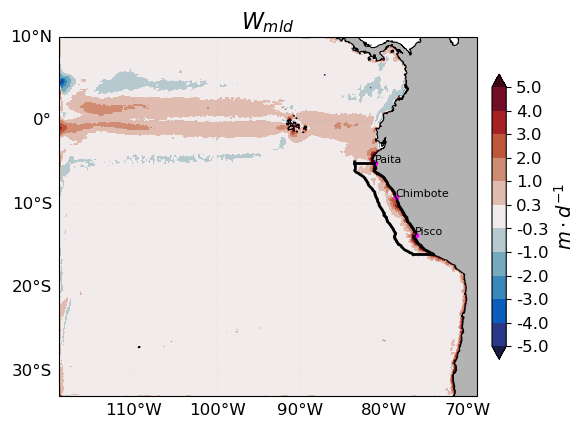

In [10]:
# ============================================================
# Custom levels highlighting ±0.5
# ============================================================
thr = 0.3
levels = np.concatenate([
    np.arange(-5, -0.5, 1),   # -5 to -1
    [-thr],                    # highlight -0.5
    [thr],                     # highlight +0.5
    np.arange(1, 6, 1)         # 1 to 5
])

vmin, vmax = -5, 5
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)

# # Set extent based on your data
# ax.set_extent([np.nanmin(loni), np.nanmax(loni), 
#                np.nanmin(lati), np.nanmax(lati)], crs=proj)

# Filled contours
cf = wmld_full_mean.plot.contourf(
    ax=ax,
    cmap=cm.cm.balance,
    levels=levels,
    norm=norm,
    extend='both',
    add_colorbar=False
)


# Map features
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, zorder=3)
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7', zorder=0)

# Gridlines
gl = ax.gridlines(crs=proj, draw_labels=True, linewidth=0.1, color='gray', 
                  alpha=0.3, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Coast, offshore and cross-shore lines
ax.plot(coast_lons + 0.05, lat_all, color='black', lw=2, transform=proj, label='Coast')
ax.plot(offshore_lons - 0.05, lat_all, color='black', lw=2, transform=proj, label='Offshore')

target_lats = [-5, -16]
for lat0 in target_lats:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c = coast_lons[j]
    lon_o = offshore_lons[j]
    
    if not (np.isfinite(lon_c) and np.isfinite(lon_o)):
        continue
        
    dx = 1.05 * abs(lon_c - lon_o)
    x0 = lon_c - np.sign(lon_c - lon_o) * dx
    x1 = lon_c
    ax.plot([x0, x1], [lat0, lat0], color='black', lw=2, zorder=5, transform=proj)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.03, shrink=0.5)
cbar.set_label(r'$m \cdot d^{-1}$', fontsize=14)

cbar.set_ticks(levels)
cbar.set_ticklabels([f"{v:.1f}" for v in levels])
cbar.ax.tick_params(labelsize=12)

ax.set_title('$W_{mld}$', fontsize=16)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)

for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax.text(x, y, key, fontsize=8)
    ax.plot(x+0.05,y, '.',color='magenta')

# Quiver (direction)
# ax.quiver(lon_, lat_, u_, v_, scale=150)
plt.tight_layout()
# plt.savefig('Figures/all_domain.png', dpi=300, bbox_inches='tight')

plt.show()

In [11]:
wmld_region = wmld.WMLD.mean('time') *60*60*24
winds_ds = xr.open_dataset('../winds_NHUS.nc').compute()
# Mean wind (or you can use std, but direction usually from mean)
u = winds_ds.u10.mean('time')
v = winds_ds.v10.mean('time')

# Subsample (VERY important)
step = 10
u_ = u[::step, ::step]
v_ = v[::step, ::step]
lon_ = winds_ds.lon[::step]
lat_ = winds_ds.lat[::step]


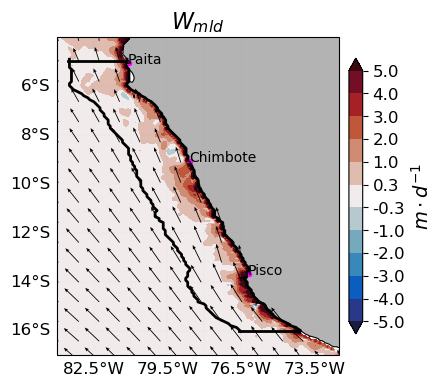

In [12]:
# ============================================================
# Custom levels highlighting ±0.5
# ============================================================
thr = 0.3
levels = np.concatenate([
    np.arange(-5, -0.5, 1),   # -5 to -1
    [-thr],                    # highlight -0.5
    [thr],                     # highlight +0.5
    np.arange(1, 6, 1)         # 1 to 5
])

vmin, vmax = -5, 5
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(4.5, 4.5))
ax = plt.axes(projection=proj)

# # Set extent based on your data
ax.set_extent([-84, -72.5, 
               -17, -4], crs=proj)

# Filled contours
cf = wmld_full_mean.plot.contourf(
    ax=ax,
    cmap=cm.cm.balance,
    levels=levels,
    norm=norm,
    extend='both',
    add_colorbar=False
)


# Map features
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, zorder=3)
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7', zorder=0)

# Gridlines
gl = ax.gridlines(crs=proj, draw_labels=True, linewidth=0.1, color='gray', 
                  alpha=0.3, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Coast, offshore and cross-shore lines
ax.plot(coast_lons + 0.05, lat_all, color='black', lw=2, transform=proj, label='Coast')
ax.plot(offshore_lons - 0.05, lat_all, color='black', lw=2, transform=proj, label='Offshore')

target_lats = [-5, -16]
for lat0 in target_lats:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c = coast_lons[j]
    lon_o = offshore_lons[j]
    
    if not (np.isfinite(lon_c) and np.isfinite(lon_o)):
        continue
        
    dx = 1.05 * abs(lon_c - lon_o)
    x0 = lon_c - np.sign(lon_c - lon_o) * dx
    x1 = lon_c
    ax.plot([x0, x1], [lat0, lat0], color='black', lw=2, zorder=5, transform=proj)

##################### Quiver (direction)
ax.quiver(
    lon_, lat_, u_, v_,
    scale=100,
    width=0.003,
    headwidth=4,
    headlength=5
)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label(r'$m \cdot d^{-1}$', fontsize=14)

cbar.set_ticks(levels)
cbar.set_ticklabels([f"{v:.1f}" for v in levels])
cbar.ax.tick_params(labelsize=12)

ax.set_title('$W_{mld}$', fontsize=16)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)

for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax.text(x, y, key, fontsize=10)
    ax.plot(x+0.05,y, '.',color='magenta')


plt.tight_layout()
# plt.savefig('Figures/Up_region.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_631877/3989730006.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


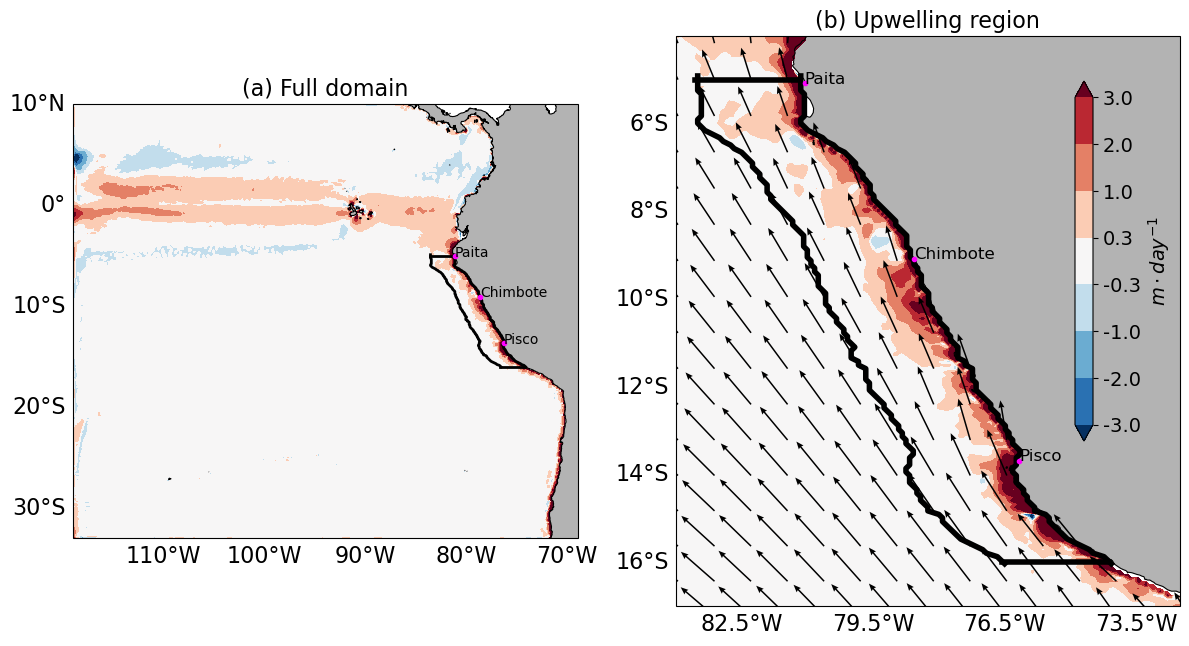

In [27]:
# ============================================================
# Levels and normalization
# ============================================================
thr = 0.3
levels = np.concatenate([
    np.arange(-3, -0.5, 1),
    [-thr],
    [thr],
    np.arange(1, 4, 1)
])

vmin, vmax = -3, 3
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

proj = ccrs.PlateCarree()

# ============================================================
# FIGURE (two panels side-by-side)
# ============================================================
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 6),
    subplot_kw={'projection': proj}
)

# ============================================================
# LEFT PANEL — Full domain
# ============================================================
cf = wmld_full_mean.plot.contourf(
    ax=ax1,
    cmap='RdBu_r',
    levels=levels,
    norm=norm,
    extend='both',
    add_colorbar=False
)

ax1.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
ax1.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7')

# Gridlines (FIXED SIZE)
gl1 = ax1.gridlines(draw_labels=True, linewidth=0, color='gray',
                    alpha=0.3, linestyle='--')
gl1.right_labels = False
gl1.top_labels = False
gl1.xlabel_style = {'size': 16}
gl1.ylabel_style = {'size': 16}

# Coast + offshore
ax1.plot(coast_lons + 0.05, lat_all, color='black', lw=2, transform=proj)
ax1.plot(offshore_lons - 0.05, lat_all, color='black', lw=2, transform=proj)

# Cross-shore lines
for lat0 in [-5, -16]:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c = coast_lons[j]
    lon_o = offshore_lons[j]

    if np.isfinite(lon_c) and np.isfinite(lon_o):
        dx = 1.05 * abs(lon_c - lon_o)
        x0 = lon_c - np.sign(lon_c - lon_o) * dx
        ax1.plot([x0, lon_c], [lat0, lat0],
                 color='black', lw=2, transform=proj)

# Ports
for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax1.text(x, y, key, fontsize=10)
    ax1.plot(x+0.05, y, '.', color='magenta')

ax1.set_title('(a) Full domain', fontsize=16)
ax1.set_xlabel('Longitude', fontsize=14)
ax1.set_ylabel('Latitude', fontsize=14)

# ============================================================
# RIGHT PANEL — Zoom
# ============================================================
cf2 = wmld_full_mean.plot.contourf(
    ax=ax2,
    cmap='RdBu_r',
    levels=levels,
    norm=norm,
    extend='both',
    add_colorbar=False
)

ax2.set_extent([-84, -72.5, -17, -4], crs=proj)

ax2.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
ax2.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7')

# Gridlines (FIXED SIZE)
gl2 = ax2.gridlines(draw_labels=True, linewidth=0, color='gray',
                    alpha=0.3, linestyle='--')
gl2.right_labels = False
gl2.top_labels = False
gl2.xlabel_style = {'size': 16}
gl2.ylabel_style = {'size': 16}

# Coast + offshore
ax2.plot(coast_lons + 0.05, lat_all, color='black', lw=4, transform=proj)
ax2.plot(offshore_lons - 0.05, lat_all, color='black', lw=4, transform=proj)

# Cross-shore lines
for lat0 in [-5, -16]:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c = coast_lons[j]
    lon_o = offshore_lons[j]

    if np.isfinite(lon_c) and np.isfinite(lon_o):
        dx = 1.05 * abs(lon_c - lon_o)
        x0 = lon_c - np.sign(lon_c - lon_o) * dx
        ax2.plot([x0, lon_c], [lat0, lat0],
                 color='black', lw=4, transform=proj)

# Quiver (slightly bigger arrows like you wanted)
ax2.quiver(
    lon_, lat_, u_, v_,
    scale=80,          # smaller = bigger arrows
    width=0.003,
    headwidth=5-1,
    headlength=6-1
)

# Ports
for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax2.text(x+0.05, y, key, fontsize=12)
    ax2.plot(x+0.05, y, '.', color='magenta')

ax2.set_title('(b) Upwelling region', fontsize=16)
ax2.set_xlabel('Longitude', fontsize=14)
ax2.set_ylabel('Latitude', fontsize=14)

# ============================================================
# SHARED COLORBAR (cleaner)
# ============================================================
cbar = fig.colorbar(
    cf,
    ax=[ax2],
    orientation='vertical',
    pad=0.15,
    shrink=1
)
cbar.ax.set_position([0.9, 0.3, 0.02, 0.6])

cbar.set_label(r'$m \cdot day^{-1}$', fontsize=14)
cbar.set_ticks(levels)
cbar.set_ticklabels([f"{v:.1f}" for v in levels])
cbar.ax.tick_params(labelsize=14)

# ============================================================
# FINAL LAYOUT
# ============================================================
plt.tight_layout()
# plt.savefig('Figures/figure1_methods.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_631877/2367462338.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels,fontsize=16)


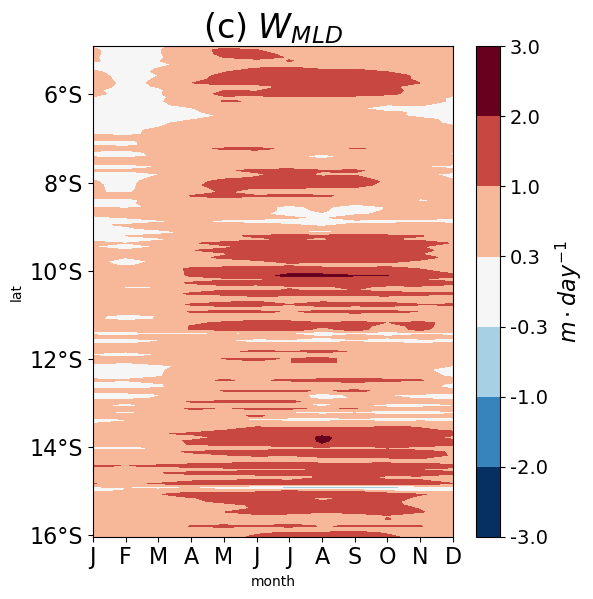

In [23]:

wmld_region = seasonality(wmld.WMLD *60*60*24).mean(dim='lon')

thr = 0.3
levels = np.concatenate([
    np.arange(-3, -0.5, 1),
    [-thr],
    [thr],
    np.arange(1, 4, 1)
])

vmin, vmax = -3, 3
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(6,6))

# levels=np.linspace(vmin,vmax,10)

cf=(wmld_region).plot.contourf(x='month',vmin=vmin, vmax=vmax,cmap = 'RdBu_r',
                                                                 norm=norm,levels=levels,add_colorbar=False)
ax = plt.gca()
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('$m \cdot day^{-1}$',fontsize=16)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=14)  # 1 decimal formatting

yticks = ax.get_yticks()  # Get current y-tick positions

# Format labels with °S for negative values (Southern Hemisphere)
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax.set_yticklabels(new_labels,fontsize=16)

plt.title('(c) $W_{MLD}$',fontsize=24)
plt.tight_layout()

months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

plt.show()

## Combined plot

/tmp/ipykernel_631877/1192043354.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(new_labels, fontsize=14)


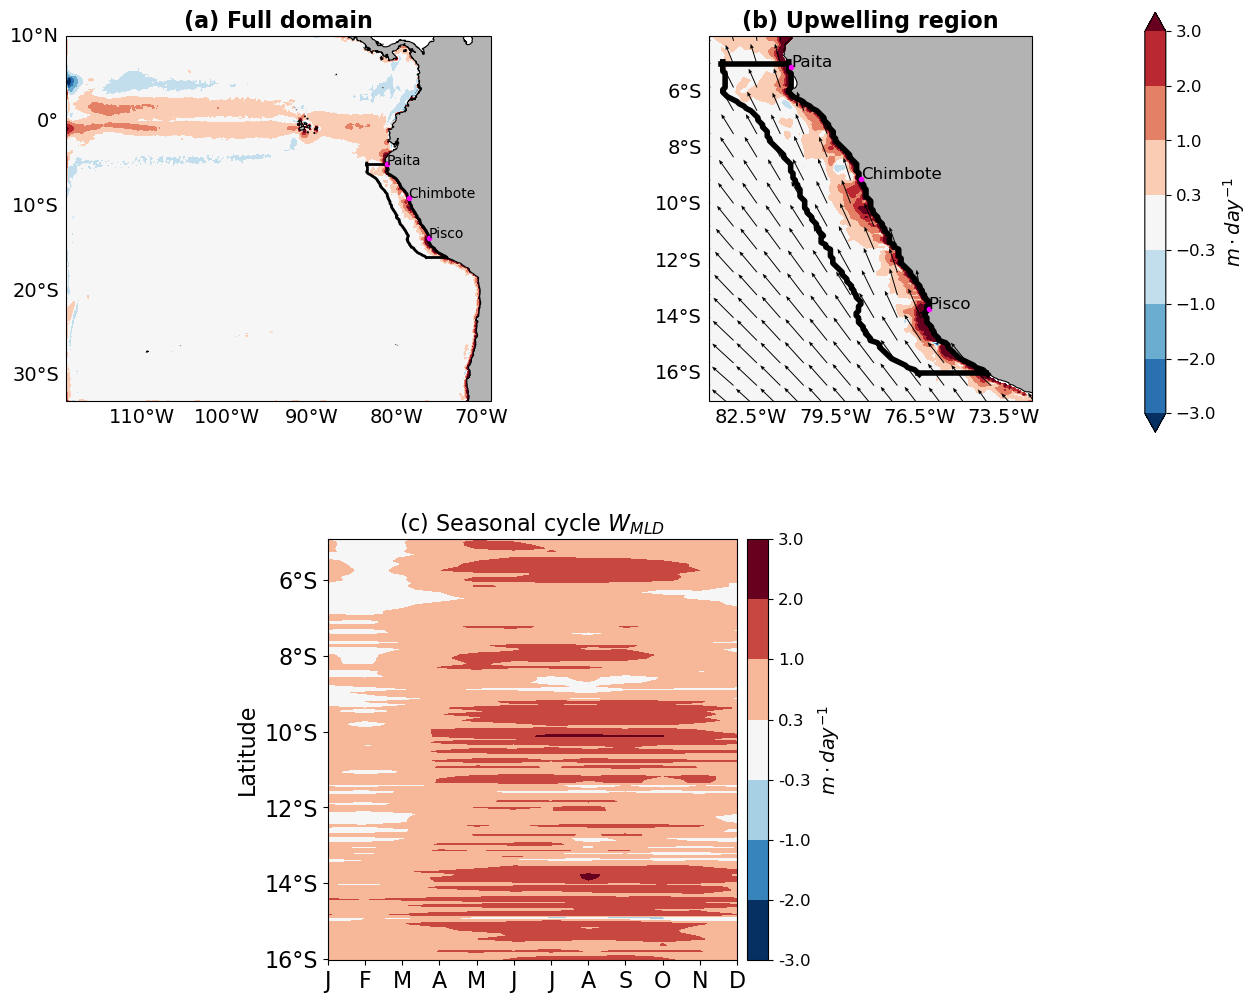

In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm

thr = 0.3
levels = np.concatenate([
    np.arange(-3, -0.5, 1),
    [-thr], [thr],
    np.arange(1, 4, 1)
])
vmin, vmax = -3, 3
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
proj = ccrs.PlateCarree()
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(2, 4,
                       height_ratios=[1.3, 1.5],
                       hspace=0.35, wspace=0.5)

ax1 = fig.add_subplot(gs[0, :2], projection=proj)   # (a) full domain
ax2 = fig.add_subplot(gs[0, 2:], projection=proj)   # (b) zoom
ax3 = fig.add_subplot(gs[1, 1:3])                   # (c) seasonal — centered

# ============================================================
# (a) Full domain
# ============================================================
cf = wmld_full_mean.plot.contourf(
    ax=ax1, cmap='RdBu_r', levels=levels, norm=norm,
    extend='both', add_colorbar=False
)
ax1.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
ax1.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7')

gl1 = ax1.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.3, linestyle='--')
gl1.right_labels = False
gl1.top_labels = False
gl1.xlabel_style = {'size': 14}
gl1.ylabel_style = {'size': 14}

ax1.plot(coast_lons + 0.05, lat_all, color='black', lw=2, transform=proj)
ax1.plot(offshore_lons - 0.05, lat_all, color='black', lw=2, transform=proj)

for lat0 in [-5, -16]:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c, lon_o = coast_lons[j], offshore_lons[j]
    if np.isfinite(lon_c) and np.isfinite(lon_o):
        dx = 1.05 * abs(lon_c - lon_o)
        x0 = lon_c - np.sign(lon_c - lon_o) * dx
        ax1.plot([x0, lon_c], [lat0, lat0], color='black', lw=2, transform=proj)

for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax1.text(x, y, key, fontsize=10)
    ax1.plot(x + 0.05, y, '.', color='magenta')

ax1.set_title('(a) Full domain', fontsize=16, fontweight='bold')

# ============================================================
# (b) Upwelling region
# ============================================================
cf2 = wmld_full_mean.plot.contourf(
    ax=ax2, cmap='RdBu_r', levels=levels, norm=norm,
    extend='both', add_colorbar=False
)
ax2.set_extent([-84, -72.5, -17, -4], crs=proj)

ax2.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
ax2.add_feature(cfeature.LAND.with_scale('10m'), facecolor='0.7')

gl2 = ax2.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.3, linestyle='--')
gl2.right_labels = False
gl2.top_labels = False
gl2.xlabel_style = {'size': 14}
gl2.ylabel_style = {'size': 14}

ax2.plot(coast_lons + 0.05, lat_all, color='black', lw=4, transform=proj)
ax2.plot(offshore_lons - 0.05, lat_all, color='black', lw=4, transform=proj)

for lat0 in [-5, -16]:
    j = np.argmin(np.abs(lat_all - lat0))
    lon_c, lon_o = coast_lons[j], offshore_lons[j]
    if np.isfinite(lon_c) and np.isfinite(lon_o):
        dx = 1.05 * abs(lon_c - lon_o)
        x0 = lon_c - np.sign(lon_c - lon_o) * dx
        ax2.plot([x0, lon_c], [lat0, lat0], color='black', lw=4, transform=proj)

ax2.quiver(lon_, lat_, u_, v_, scale=80, width=0.003, headwidth=4, headlength=5)

for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax2.text(x + 0.05, y, key, fontsize=12)
    ax2.plot(x + 0.05, y, '.', color='magenta')

ax2.set_title('(b) Upwelling region', fontsize=16, fontweight='bold')

# Shared colorbar for maps
cbar_ax = fig.add_axes([0.92, 0.55, 0.015, 0.35])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'$m \cdot day^{-1}$', fontsize=14)
cbar.set_ticks(levels)
cbar.set_ticklabels([f"{v:.1f}" for v in levels])
cbar.ax.tick_params(labelsize=12)

# ============================================================
# (c) Seasonal cycle — centered bottom
# ============================================================
wmld_region = seasonality(wmld.WMLD * 60 * 60 * 24).mean(dim='lon')

cf3 = wmld_region.plot.contourf(
    ax=ax3, x='month',
    vmin=vmin, vmax=vmax,
    cmap='RdBu_r', norm=norm, levels=levels,
    add_colorbar=False
)

cbar3 = fig.colorbar(cf3, ax=ax3, orientation='vertical', pad=0.02)
cbar3.set_label(r'$m \cdot day^{-1}$', fontsize=14)
cbar3.set_ticks(levels)
cbar3.set_ticklabels([f"{tick:.1f}" for tick in levels])
cbar3.ax.tick_params(labelsize=12)

yticks = ax3.get_yticks()
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax3.set_yticklabels(new_labels, fontsize=14)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(months, fontsize=16)
ax3.set_xlabel('')
ax3.set_ylabel('Latitude', fontsize=16)
ax3.set_title(r'(c) Seasonal cycle $W_{MLD}$', fontsize=16)
ax3.tick_params(axis='both', labelsize=16)

# plt.savefig('Figures/figure1_methods_combined_.png', dpi=300, bbox_inches='tight')

plt.show()